In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
df = pd.read_csv("attaque_cardiaque.csv")
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45.0,0,582,1,55,0,543000.00,1.0,132,0,0,250,0
4996,60.0,1,582,0,30,1,127000.00,0.9,145,0,0,95,0
4997,95.0,1,112,0,40,1,196000.00,1.0,138,0,0,24,1
4998,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# valeurs manquantes
df.isna().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
# checking des valeurs dupliquées
df.duplicated().sum()

np.int64(3680)

In [ ]:
df.shape

(5000, 13)

In [ ]:
# separer X et yy
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [ ]:
y

,DEATH_EVENT
0,0
1,0
2,0
3,0
4,1
...,...
4995,0
4996,0
4997,1
4998,1


In [ ]:
y.value_counts()

,count
DEATH_EVENT,
0,3432
1,1568


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# standardiser
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

PYTORCH CLASSIFICATION

In [ ]:
# transformation des array en tenseurs avec pytorch
import torch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [ ]:
# MODELE
from torch import nn
class cardiac_model(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=X_train.shape[1], out_features=8)
    self.layer2 = nn.Linear(in_features=8, out_features=4)
    self.layer3 = nn.Linear(in_features=4, out_features=1)
    # on ajoute les fonctions d'activation
    self.relu = nn.ReLU()

  # forward propagation
  def forward(self, x):
      return  self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model = cardiac_model()
model

cardiac_model(
  (layer1): Linear(in_features=12, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (layer3): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# fonction loss
# elle permettra de calculer les probabilités (choisir la sortie) 0 ou 1
Loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)


In [ ]:
# calculer le accuracy
# torch.eq (lorsque c'est supérieur à 0.5, mets 1 sinon mets 0)
def accuracy_fn(y_train_t,y_pred):
    correct = torch.eq(y_pred,y_train_t).sum().item()
    acc =(correct/len(y_pred))*100
    return acc

In [ ]:
# création listes vides
epoch_count = []
train_acc_list = []
test_acc_list = []
train_lost_list = []
test_lost_list = []

# training
torch.manual_seed(42)
epochs = 2000
for epoch in range(epochs):
  # mode training
  model.train()
  # forward pass
  y_logits = model(X_train).squeeze() # calcule des probabilité
  y_pred = torch.round(torch.sigmoid(y_logits))
  # calculate loss et accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)
  # optimizer zero grad
  optimizer.zero_grad()
  # loss backpropagation
  loss.backward()
  # optimizer step
  optimizer.step()

  # mode testing
  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # calcul du test lost et accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)


    # afficher les resultats
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_acc_list.append(acc)
      test_acc_list.append(test_acc)
      train_lost_list.append(loss)
      test_lost_list.append(test_loss)

    print(f'Epoch:{epoch}, | Loss:{loss:.5f} | Acc= {acc:.2f}% |Test loss:{test_loss:.5f} |Test acc:{test_acc:.2f}')

Epoch:0, | Loss:0.20635 | Acc= 93.25% |Test loss:0.25193 |Test acc:91.50
Epoch:1, | Loss:0.20634 | Acc= 92.90% |Test loss:0.25182 |Test acc:91.90
Epoch:2, | Loss:0.20636 | Acc= 93.25% |Test loss:0.25191 |Test acc:91.60
Epoch:3, | Loss:0.20633 | Acc= 92.90% |Test loss:0.25184 |Test acc:91.90
Epoch:4, | Loss:0.20631 | Acc= 93.25% |Test loss:0.25193 |Test acc:91.90
Epoch:5, | Loss:0.20633 | Acc= 93.25% |Test loss:0.25188 |Test acc:91.90
Epoch:6, | Loss:0.20629 | Acc= 93.25% |Test loss:0.25187 |Test acc:91.90
Epoch:7, | Loss:0.20630 | Acc= 93.25% |Test loss:0.25187 |Test acc:91.90
Epoch:8, | Loss:0.20631 | Acc= 93.25% |Test loss:0.25189 |Test acc:91.90
Epoch:9, | Loss:0.20627 | Acc= 93.25% |Test loss:0.25186 |Test acc:91.50
Epoch:10, | Loss:0.20628 | Acc= 92.90% |Test loss:0.25187 |Test acc:91.90
Epoch:11, | Loss:0.20629 | Acc= 93.25% |Test loss:0.25183 |Test acc:91.90
Epoch:12, | Loss:0.20626 | Acc= 93.25% |Test loss:0.25190 |Test acc:91.90
Epoch:13, | Loss:0.20626 | Acc= 93.25% |Test los

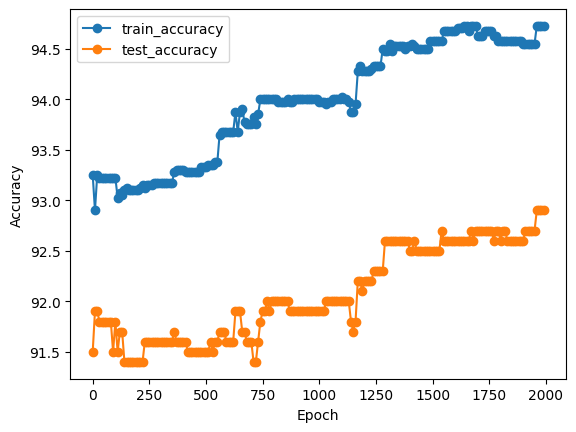

In [ ]:
# revert to numpy array
train_acc_list = np.array(torch.tensor(train_acc_list))
test_acc_list = np.array(torch.tensor(test_acc_list))

plt.plot(epoch_count, train_acc_list, label='train_accuracy', marker='o')
plt.plot(epoch_count, test_acc_list, label='test_accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

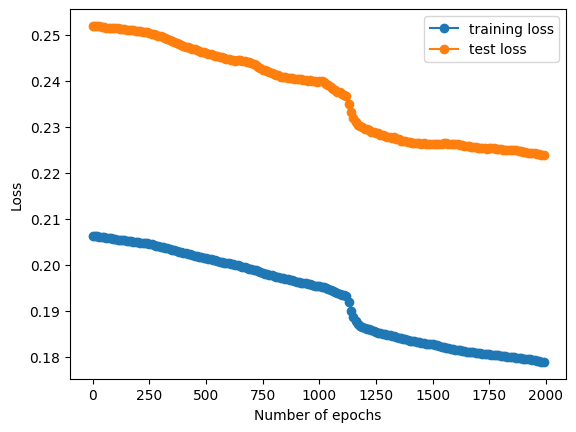

In [ ]:
train_loss_list = np.array(torch.tensor(train_lost_list))
test_loss_list = np.array(torch.tensor(test_lost_list))

plt.plot(epoch_count,train_loss_list,label='training loss',marker='o')
plt.plot(epoch_count,test_loss_list,label='test loss',marker='o')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.legend()

<Axes: >

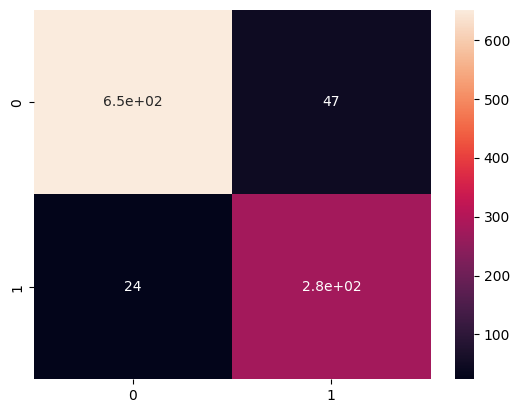

In [ ]:
from sklearn.metrics import confusion_matrix
model_matrix = confusion_matrix(y_test, test_pred)
model_matrix
sns.heatmap(model_matrix, annot=True)

<Axes: >

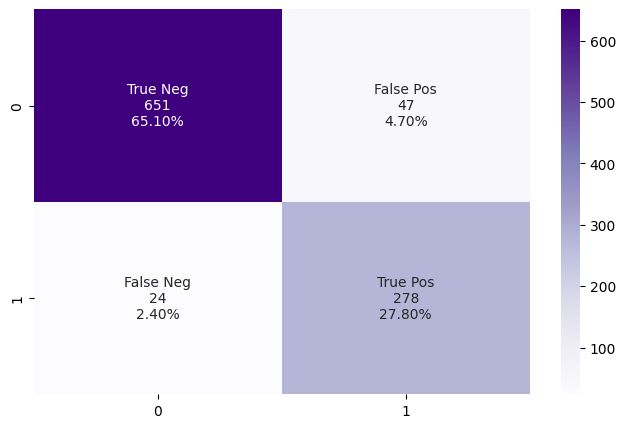

In [ ]:
# matrice de corrélation
# Visualize
fig, ax = plt.subplots(figsize=(8,5))
# setting variables
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ['{0:0.0f}'.format(value) for value in model_matrix.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in model_matrix.flatten()/np.sum(model_matrix)]
labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(model_matrix, annot=labels, fmt='', cmap='Purples')

In [ ]:
liste = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT']
formatted_output = ""
for i, element in enumerate(liste):
    formatted_output += element
    if i != len(liste) - 1:
        formatted_output += ", "
print(formatted_output)

age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT


In [ ]:
def prediction_sample(age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time):
  sample = np.array([age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time])
  sample = torch.from_numpy(sample).type(torch.float)
  model.eval()
  with torch.inference_mode():
    sample.logits = model(sample).squeeze()
    sample_pred = torch.round(torch.sigmoid(sample.logits))
  return sample_pred

prediction_sample(60.0,1,34,0,20,0,204000,0,0.7,139,1,73)

tensor(1.)